# Spectral Feature Labeler — species & rest-wavelength identification

Takes the feature list produced by `spectral_lines_finder_2.ipynb` (wavelength, amplitude, FWHM
per detected/deblended feature) and attaches **2–3 candidate atomic-species labels** (4 in
extreme cases) to each feature, using a stellar-parameter-dependent line list instead of a
generic static database.

**Why not just match against VALD/NIST directly?** At R≈850 a "feature" is almost always a blend
of several real transitions, and *which one dominates* depends on the star's Teff/log g/abundances
— a hot B star and a cool F supergiant will have completely different dominant contributors at the
same wavelength window. A generic line list has no way to know that. VALD's **"Extract Stellar"**
mode does: you give it Teff/log g/[Fe/H]/vmic and it returns each line's *expected central depth*
for that specific star, computed under LTE from a real model atmosphere — exactly the ranking
signal we need.

**Runs 100% natively on Windows 11** — no compiled radiative-transfer code, no WSL, no Linux.
Everything here is plain Python (numpy / scipy / pandas / matplotlib / astropy), all of which ship
as prebuilt Windows wheels:
```
pip install numpy scipy pandas matplotlib astropy
```

## Before running this notebook: get a VALD "Extract Stellar" line list

1. Register (free) at **http://vald.astro.uu.se**.
2. Log in → **Extract Stellar**.
3. Fill in:
   - **Starting / ending wavelength**: cover your spectrum's full range (e.g. 3600–6900 Å).
   - **Teff / log g / [Fe/H] / microturbulence**: your best estimate for the target star
     (a rough spectral-type-calibration value is fine — this drives *relative* line-depth
     ranking, not a precision abundance analysis).
   - **Detection threshold**: ~0.01 (keeps weak lines that can still matter in a blend).
   - **Line list format**: long format, with central depths included.
4. Submit — VALD emails you a `.gz`/`.txt` result file. Save the **long-format data file**
   (not the reference/bibliography file) somewhere on disk and point `VALD_FILE` at it below.

If you don't have a file yet, leave `USE_DEMO_VALD = True` — the notebook will use a small
hand-built example line list so you can verify the whole pipeline runs before plugging in a
real VALD extraction. **Labels produced in demo mode are illustrative only, not real IDs.**

Pick a Teff appropriate to the star's class — as a rough guide from the stars tested so far in
this project: B3 IV ≈ 17500 K, B9 III ≈ 10000 K, A1 III-IV ≈ 9000 K, F8 Iab ≈ 6100 K. You can
cross-check your labeled output against known bright-star spectra at
**https://amattioli.github.io/spectra/Index.html** as a sanity check (it won't give you
per-line species IDs, but it's a good "does this look like a normal star of this class" check).

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 140)
print('Imports OK — numpy', np.__version__, '| pandas', pd.__version__)

Imports OK — numpy 2.4.6 | pandas 3.0.3


## 1 · Configuration

In [2]:
# ── Inputs ──────────────────────────────────────────────────────────────────
FEATURES_CSV   = 'atlas_features.csv'                              # output of spectral_lines_finder_2.ipynb
SPEC_FITS_RECT = '_atlas_20260111_730-rect.fit'      # normalised spectrum (for plotting only)

USE_DEMO_VALD  = False     # ← set False once you have a real VALD Extract Stellar file
VALD_FILE      = 'atlas_vald.txt'   # ← path to your downloaded VALD long-format file

# ── Star parameters (must match what you requested from VALD) ───────────────
TEFF   = 12525    # K   — effective temperature used for the VALD Extract Stellar request
VMIC   = 0.5      # km/s — microturbulence used for the VALD Extract Stellar request
R_SPEC = 850      # resolving power of the observed spectrum (Alpy 600 @ ASI533MM Pro ≈ 850)
VSINI  = 217.0     # km/s — projected rotational velocity, if known; 0 if unknown/negligible

# ── Labeling parameters (all tunable) ────────────────────────────────────────
WINDOW_NFWHM       = 1.5    # candidate VALD lines are searched within ± WINDOW_NFWHM × feature FWHM of its center
MAX_LABELS         = 3      # normal cap on number of species labels per feature
MAX_LABELS_EXTREME = 4      # hard ceiling, used only when contributions are near-tied
MIN_CONTRIB_FRAC   = 0.30   # once the cumulative target below is met, drop any straggler line that
                             # individually explains less than this fraction of the blend on its own
TOP_CONTRIB_MIN_FRAC   = 0.15   # if even the SINGLE strongest line in a window explains less than this,
                                 # the feature is a genuine many-line forest with no dominant contributor --
                                 # naming 2-3 "the" species would be arbitrary, so it's reported honestly as
                                 # an unresolved blend instead of forced into labels
CUMULATIVE_CONTRIB_TARGET = 0.75   # keep adding contributors, strongest first, until they cumulatively
                                    # explain at least this fraction of the total modeled blend depth
MIN_CONFIRM_FRAC   = 0.35   # modeled/observed depth ratio below this → discard as uncertain (leave unlabeled)
MAX_CONFIRM_FRAC   = 25.0    # modeled/observed depth ratio above this → discard as uncertain (over-predicted, likely wrong Teff or missing lines)
AIR_WAVELENGTHS    = True   # VALD's default (>2000 Å) and standard ground-based spectrograph calibration — leave True unless you requested vacuum

BALMER_LINES = [
    {"name":"Hα", "wl":6562.8},
    {"name":"Hβ", "wl":4861.4},
    {"name":"Hγ", "wl":4340.5},
    {"name":"Hδ", "wl":4101.7},
    {"name":"Hε", "wl":3970.1},
    {"name":"H-8", "wl":3889.0},
    {"name":"H-9", "wl":3835.4},
    {"name":"H-10", "wl":3797.9},
    {"name":"H-11", "wl":3770.6},
    {"name":"H-12", "wl":3750.2},
    {"name":"H-13", "wl":3734.4},
    {"name":"H-14", "wl":3721.9},
    {"name":"H-15", "wl":3712.0},
    {"name":"H-16", "wl":3703.9},
    {"name":"H-17", "wl":3697.2}
]

print(f'Teff={TEFF} K   vmic={VMIC} km/s   R={R_SPEC}   vsini={VSINI} km/s')
print(f'Window: ±{WINDOW_NFWHM}×FWHM   Confirm range: [{MIN_CONFIRM_FRAC}, {MAX_CONFIRM_FRAC}]× observed depth')

Teff=12525 K   vmic=0.5 km/s   R=850   vsini=217.0 km/s
Window: ±1.5×FWHM   Confirm range: [0.35, 25.0]× observed depth


## 2 · Load the detected-feature list

Reads the CSV produced by `spectral_lines_finder_2.ipynb` (columns:
`wavelength_A, amplitude, fwhm_A, profile, source, balmer_name, tag`).

In [3]:
features = pd.read_csv(FEATURES_CSV, encoding='utf-8-sig')
features.columns = [c.strip() for c in features.columns]
required = {'wavelength_A', 'amplitude', 'fwhm_A', 'tag'}
missing = required - set(features.columns)
if missing:
    raise ValueError(f'Features CSV is missing expected column(s): {missing}. '
                      f'Found columns: {list(features.columns)}')

print(f'Loaded {len(features)} features from {FEATURES_CSV}')
print(f'  Balmer : {(features.tag == "Balmer").sum()}')
print(f'  Other  : {(features.tag == "other").sum()}')
features.head(10)

Loaded 59 features from atlas_features.csv
  Balmer : 7
  Other  : 52


,wavelength_A,amplitude,fwhm_A,profile,source,balmer_name,tag
0,3734.54,0.2444,6.81,Gaussian,single,NaN,other
1,3750.11,0.3515,7.93,Gaussian,single,NaN,other
2,3770.57,0.4121,9.34,Gaussian,single,NaN,other
3,3797.82,0.4661,10.45,Gaussian,single,NaN,other
4,3835.33,0.4846,10.76,Voigt,deblended,H-9,Balmer
5,3889.09,0.4968,11.47,Voigt,single,H-8,Balmer
6,3934.09,0.0233,5.64,Gaussian,single,NaN,other
7,3970.15,0.5033,12.09,Voigt,single,Heps,Balmer
8,4026.49,0.0543,6.85,Gaussian,single,NaN,other
9,4093.37,0.0079,8.26,Gaussian,deblended,NaN,other


## 3 · Load the VALD "Extract Stellar" line list

VALD's raw export mixes a header block, the data rows, and a bibliography footer, with slight
format variations between requests. The parser below auto-detects the header row (looks for a
column named like `WL_air`/`WL_vac`/`Wavelength`) and the `Central depth` column, then extracts
every data row matching the `'Elm Ion', wavelength, ...` pattern. If your file doesn't parse
cleanly, the diagnostic printout below will show exactly what was (and wasn't) recognized —
adjust `MANUAL_COLUMN_MAP` in that case (see the fallback cell).

In [4]:
# Demo line list (used only when USE_DEMO_VALD = True) -- real rest wavelengths for real
# transitions, but illustrative placeholder depths, NOT a real LTE calculation for any
# specific Teff. Do not use these labels as genuine line identifications. Formatted to match
# VALD Extract Stellar's real 14-field layout (species, WL_air, log gf*, E_low, J_lo, E_up,
# J_up, lower/upper/mean Lande, Rad/Stark/Waals damping, Central depth) so the demo exercises
# the exact same parsing path as a real download -- Lande/damping placeholders use VALD's own
# convention for "not available" (99.000 / 0.000).
def make_demo_vald_file(path):
    header = ("Elm Ion       WL_air(A)   log gf*  E_low(eV) J lo  E_up(eV)  J up  lower  "
              "upper   mean   Rad.   Stark  Waals  depth\n")
    rows = [
        "'H 1',   4101.734, -2.845, 10.199, 1.0, 13.221, 2.0, 99.000, 99.000, 99.000, 8.400, -4.061, 0.000, 0.550,",
        "'H 1',   4340.472, -2.548, 10.199, 1.0, 13.055, 2.0, 99.000, 99.000, 99.000, 8.400, -4.161, 0.000, 0.520,",
        "'H 1',   4861.350, -2.302, 10.199, 1.0, 12.749, 2.0, 99.000, 99.000, 99.000, 8.370, -4.261, 0.000, 0.480,",
        "'H 1',   6562.797, -1.342, 10.199, 1.0, 12.088, 2.0, 99.000, 99.000, 99.000, 8.766, -4.522, 0.000, 0.550,",
        "'Ca 2',  3933.663,  0.105,  0.000, 0.5,  3.151, 1.5, 1.200, 0.870, 1.040, 8.410, -5.550, -7.220, 0.750,",
        "'Ca 2',  3968.469, -0.166,  0.000, 0.5,  3.123, 0.5, 1.200, 1.200, 1.200, 8.410, -5.550, -7.220, 0.600,",
        "'Ca 1',  4226.728,  0.244,  0.000, 1.0,  2.933, 1.0, 0.000, 1.000, 0.500, 8.230, -5.680, -7.520, 0.180,",
        "'Sr 2',  4077.709,  0.146,  0.000, 0.5,  3.041, 1.5, 1.200, 0.870, 1.040, 8.550, -5.700, -7.300, 0.090,",
        "'Si 2',  4128.054,  0.359,  9.837, 0.5, 12.842, 1.5, 0.670, 1.330, 1.000, 8.800, -5.640, -7.500, 0.060,",
        "'Si 2',  4130.872,  0.633,  9.837, 0.5, 12.839, 0.5, 0.670, 0.670, 0.670, 8.800, -5.640, -7.500, 0.070,",
        "'Mg 2',  4481.126,  0.749,  8.864, 2.5, 11.632, 1.5, 1.200, 0.800, 1.000, 8.860, -5.630, -7.390, 0.070,",
        "'Mg 2',  4481.325, -0.560,  8.864, 1.5, 11.632, 1.5, 1.330, 0.800, 1.070, 8.860, -5.630, -7.390, 0.030,",
        "'Fe 1',  4045.812,  0.280,  1.485, 3.0,  4.549, 4.0, 1.480, 1.200, 1.340, 7.870, -6.160, -7.330, 0.140,",
        "'Fe 1',  4271.760, -0.164,  1.485, 3.0,  4.388, 3.0, 1.480, 1.500, 1.490, 7.870, -6.160, -7.330, 0.120,",
        "'Fe 1',  4383.545,  0.200,  1.485, 3.0,  4.313, 4.0, 1.480, 1.200, 1.340, 7.870, -6.160, -7.330, 0.150,",
        "'Fe 2',  4923.927, -1.320,  2.891, 3.5,  5.408, 4.5, 0.960, 1.400, 1.180, 8.720, -6.160, -7.330, 0.090,",
        "'Ti 2',  4300.049,  0.270,  1.180, 2.5,  4.063, 3.5, 1.100, 1.180, 1.140, 8.100, -6.020, -7.400, 0.060,",
        "'CH 1',  4300.500, -1.500,  0.520, 0.0,  3.402, 1.0, 99.000, 99.000, 99.000, 0.000, 0.000, 0.000, 0.200,",
        "'Na 1',  5889.951,  0.108,  0.000, 0.5,  2.104, 1.5, 1.200, 0.670, 0.930, 7.980, -5.610, -7.360, 0.200,",
        "'Na 1',  5895.924, -0.194,  0.000, 0.5,  2.104, 0.5, 1.200, 1.330, 1.270, 7.980, -5.610, -7.360, 0.150,",
        "'He 1',  4471.479,  0.006, 20.964, 2.0, 23.736, 1.0, 99.000, 99.000, 99.000, 0.000, -3.690, 0.000, 0.400,",
        "'He 1',  4026.190, -0.001, 20.964, 2.0, 23.343, 3.0, 99.000, 99.000, 99.000, 0.000, -3.690, 0.000, 0.350,",
    ]
    with open(path, 'w') as f:
        f.write(header)
        f.write('\n'.join(rows) + '\n')

DATA_LINE_RE = re.compile(r"^\s*'([A-Za-z]{1,2})\s*(\d)'\s*,\s*([\d.]+)")

# VALD Extract Stellar's long-format data rows have a fixed, documented comma-separated
# layout (confirmed against a real download): species, WL_air, log gf*, E_low, J_lo, E_up,
# J_up, lower Lande, upper Lande, mean Lande, Rad damping, Stark damping, Waals damping,
# Central depth[, ] -- 14 real fields plus a trailing comma. This is tried FIRST since it's
# exact when it matches; the header-text search below is a fallback for files with a
# different column count (e.g. a different VALD output mode).
KNOWN_LONG_FORMAT = dict(wl_idx=1, loggf_idx=2, elow_idx=3, stark_idx=11, depth_idx=13, n_fields=14)

def _try_known_long_format(data_lines):
    field_counts = [len(l.split(',')) for l in data_lines[:50]]
    # allow for the trailing empty field from the trailing comma (14 real + 1 empty = 15)
    if field_counts and all(fc in (KNOWN_LONG_FORMAT['n_fields'], KNOWN_LONG_FORMAT['n_fields'] + 1)
                            for fc in field_counts):
        return KNOWN_LONG_FORMAT
    return None

# Fallback: locate the real column-header row by looking for VALD's specific WL_air/WL_vac
# token FIRST (unambiguous), only falling back to the generic word 'Wavelength' if neither
# is present -- some VALD files mention 'Wavelength region' in an earlier metadata line,
# which would otherwise be matched first by mistake.
def _header_text_search(raw_lines):
    for pattern in (r'WL_air|WL_vac', r'Wavelength'):
        for i, line in enumerate(raw_lines):
            if re.search(pattern, line, re.IGNORECASE):
                cols = re.split(r'\s{2,}', line.strip())
                return i, cols
    return None, None

# VALD Extract-Stellar parser. Returns a DataFrame with columns
# [element, ion, wavelength_A, depth, loggf, e_low].
def parse_vald_file(path):
    path = Path(path)
    raw_lines = path.read_text(errors='replace').splitlines()

    data_line_idx = [i for i, l in enumerate(raw_lines) if DATA_LINE_RE.match(l)]
    if not data_line_idx:
        preview = '\n'.join(raw_lines[:8])
        raise ValueError(
            "No lines matched the expected VALD data-row pattern ('Elm Ion', wavelength, ...).\n"
            'First 8 lines of the file were:\n' + preview +
            '\n\nUse the manual-mapping fallback cell below instead.'
        )
    data_lines = [raw_lines[i] for i in data_line_idx]

    layout = _try_known_long_format(data_lines)
    if layout is not None:
        wl_idx, loggf_idx, elow_idx, depth_idx, stark_idx = (
            layout['wl_idx'], layout['loggf_idx'], layout['elow_idx'],
            layout['depth_idx'], layout['stark_idx'])
        print('Recognized VALD Extract Stellar long-format layout '
              f'({layout["n_fields"]} fields/row, verified against {len(data_lines)} data rows).')
        print(f'  wavelength column index : {wl_idx}')
        print(f'  central depth column idx: {depth_idx}  (FOUND -- using real Teff-dependent depths)')
    else:
        header_idx, header_cols = _header_text_search(raw_lines)
        if header_idx is None:
            preview = '\n'.join(raw_lines[:8])
            raise ValueError(
                'Data rows were found, but their column count did not match the known VALD '
                'long-format layout, and no header row could be located either.\n'
                'First 8 lines of the file were:\n' + preview +
                '\n\nUse the manual-mapping fallback cell below instead.'
            )

        def find_col(cols, *keywords):
            for i, c in enumerate(cols):
                cl = c.lower()
                if all(k.lower() in cl for k in keywords):
                    return i
            return None

        wl_idx    = find_col(header_cols, 'wl') or find_col(header_cols, 'wavelength')
        depth_idx = find_col(header_cols, 'depth')
        loggf_idx = find_col(header_cols, 'gf')
        elow_idx  = find_col(header_cols, 'e_low') or find_col(header_cols, 'low')
        stark_idx = find_col(header_cols, 'stark')

        print('Column count did not match the known long-format layout -- fell back to '
              'header-text search.')
        print('Detected header columns:', header_cols)
        print(f'  wavelength column index : {wl_idx}')
        depth_note = '(FOUND -- using real Teff-dependent depths)' if depth_idx is not None \
            else '(NOT FOUND -- will fall back to a log gf / E_low proxy, see warning below)'
        print(f'  central depth column idx: {depth_idx}  {depth_note}')

    records = []
    for line in data_lines:
        m = DATA_LINE_RE.match(line)
        elm, ion = m.group(1), m.group(2)
        fields = [f.strip().strip("'").strip('"') for f in line.split(',')]
        try:
            wl = float(fields[wl_idx]) if wl_idx is not None else float(fields[1])
        except (ValueError, IndexError):
            continue
        depth = None
        if depth_idx is not None:
            try:
                depth = float(fields[depth_idx])
            except (ValueError, IndexError):
                depth = None
        loggf = elow = stark = None
        if loggf_idx is not None:
            try:
                loggf = float(fields[loggf_idx])
            except (ValueError, IndexError):
                pass
        if elow_idx is not None:
            try:
                elow = float(fields[elow_idx])
            except (ValueError, IndexError):
                pass
        if stark_idx is not None:
            try:
                stark = float(fields[stark_idx])
                if stark == 0.0:
                    stark = None   # VALD's sentinel for "not computed for this line"
            except (ValueError, IndexError):
                pass
        records.append(dict(element=elm, ion=int(ion), wavelength_A=wl,
                            depth=depth, loggf=loggf, e_low=elow, log_stark=stark))

    df = pd.DataFrame.from_records(records)
    if df.empty:
        raise ValueError('No data rows could be parsed into numeric fields. '
                          'See the manual-mapping fallback cell.')

    if df['depth'].isna().all():
        print()
        print('WARNING: no Central depth column found in this file -- VALD Extract Stellar')
        print('should include one. Falling back to a Boltzmann-weighted log gf / E_low proxy,')
        print('which does NOT account for element abundance or ionization balance and will')
        print('be unreliable for ranking lines of DIFFERENT species against each other.')
        print('Re-check that you used Extract Stellar (not Extract Element/All) on VALD.')
        k_eV = 8.617333e-5  # eV/K
        gf = df['loggf'].fillna(-2.0).apply(lambda x: 10 ** x)
        boltz = np.exp(-df['e_low'].fillna(0.0) / (k_eV * TEFF))
        df['depth'] = gf * boltz
        df['depth'] /= df['depth'].max()

    print(f'Parsed {len(df)} VALD lines spanning {df.wavelength_A.min():.1f}-{df.wavelength_A.max():.1f} A')
    return df

if USE_DEMO_VALD:
    demo_path = 'DEMO_vald_extract_stellar.txt'
    make_demo_vald_file(demo_path)
    VALD_FILE = demo_path
    print(f'USE_DEMO_VALD=True -- wrote a small illustrative line list to {demo_path}')
    print('Replace with a real VALD Extract Stellar download and set USE_DEMO_VALD=False for real IDs.')
    print()

vald = parse_vald_file(VALD_FILE)
vald.head(10)


Recognized VALD Extract Stellar long-format layout (14 fields/row, verified against 3153 data rows).
  wavelength column index : 1
  central depth column idx: 13  (FOUND -- using real Teff-dependent depths)
Parsed 3153 VALD lines spanning 3602.6-6899.9 A


,element,ion,wavelength_A,depth,loggf,e_low,log_stark
0,Fe,2,3602.6011,0.026,-3.406,4.0761,-6.53
1,Cr,2,3603.6152,0.172,-1.600,2.7056,-6.53
2,Cr,2,3603.7727,0.199,-1.510,2.7058,-6.53
3,Cr,2,3603.8278,0.096,-1.930,2.7058,-6.53
4,Os,2,3604.4710,0.028,0.620,1.4449,NaN
5,Co,2,3605.9838,0.019,-1.958,2.6811,-6.56
6,Fe,1,3606.6790,0.023,0.323,2.6924,-6.09
7,Ni,2,3608.8091,0.192,-2.346,3.1041,-6.63
8,Fe,1,3608.8589,0.056,-0.100,1.0111,-6.05
9,Fe,2,3609.7419,0.017,-1.147,9.0577,-5.68


### 3b · Manual column-mapping fallback

If the parser above raised an error because your VALD file's header doesn't match the expected
keywords, fill in the column *positions* (0-indexed, counting from the start of a data row) by
hand here and re-run this cell instead of the one above.

In [5]:
MANUAL_COLUMN_MAP = None
# Example -- uncomment and adjust if the automatic parser failed:
# MANUAL_COLUMN_MAP = dict(wl_idx=1, depth_idx=9, loggf_idx=2, elow_idx=3)

if MANUAL_COLUMN_MAP is not None:
    raw_lines = Path(VALD_FILE).read_text(errors='replace').splitlines()
    records = []
    for line in raw_lines:
        m = DATA_LINE_RE.match(line)
        if not m:
            continue
        elm, ion = m.group(1), m.group(2)
        fields = [f.strip().strip("'\"") for f in line.split(',')]
        try:
            wl = float(fields[MANUAL_COLUMN_MAP['wl_idx']])
            depth = float(fields[MANUAL_COLUMN_MAP['depth_idx']])
        except (ValueError, IndexError, KeyError):
            continue
        records.append(dict(element=elm, ion=int(ion), wavelength_A=wl, depth=depth,
                            loggf=None, e_low=None, log_stark=None))
    vald = pd.DataFrame.from_records(records)
    print(f'Manually parsed {len(vald)} VALD lines.')
    display(vald.head(10))
else:
    print('Manual mapping not used (automatic parser succeeded above).')


Manual mapping not used (automatic parser succeeded above).


## 4 · Labeling algorithm

For each detected feature (center λ₀, FWHM from the deblending fit):

1. Build the **instrumental+rotational broadening** σ_broad combining the instrument
   (`λ₀ / (R × 2.3548)`) and rotation (`λ₀ × vsini / c / 2.3548`, added in quadrature) — the
   same physical broadening that produced the feature's own fitted width.
2. Collect every VALD line within `± WINDOW_NFWHM × FWHM` of λ₀.
3. **Dilute each candidate's intrinsic depth for the loss of resolution.** VALD's central
   depth is the line's *intrinsic* depth at essentially infinite resolving power. At R≈850 a
   narrow intrinsic line gets smeared across a much wider instrumental profile, which reduces
   its *peak* depth substantially — equivalent width is conserved, peak depth is not. Each
   candidate is modeled as a Gaussian with its own intrinsic width σᵢ (thermal Doppler for
   that element at `TEFF`, combined with `VMIC`), convolved with the instrumental+rotational
   Gaussian: the combined width is `σ_total = sqrt(σᵢ² + σ_broad²)`, and the peak is diluted
   by the ratio `σᵢ / σ_total`. Skipping this step was the single biggest source of error
   found while testing this notebook against ι Her — it made every strong line look 5–15×
   deeper than observed.
4. **Combine contributions in optical-depth space, not depth space.** VALD also lists each
   fine-structure/multiplet component of a transition as a separate line — e.g. He I 4471 is
   really 6 separate VALD entries within 0.2 Å of each other. Real absorption saturates
   (optical depths add; depths themselves don't), so each candidate's diluted, offset-weighted
   contribution is expressed as an optical depth τᵢ, all τᵢ are summed, and only then converted
   back to a predicted blend depth via `1 − exp(−Στᵢ)`.
5. Compare the predicted blend depth against the feature's *observed* fitted amplitude:
   - if the ratio falls outside `[MIN_CONFIRM_FRAC, MAX_CONFIRM_FRAC]`, the identification is
     **discarded** (left unlabeled) — the candidate lines don't actually explain what was
     observed, so guessing would be worse than saying nothing.
   - otherwise, rank candidates by their individual τ-contribution fraction and keep the top
     `MAX_LABELS` (or up to `MAX_LABELS_EXTREME` only when several contributions are close to
     tied at the cutoff), each contributing at least `MIN_CONTRIB_FRAC` of the total.

This is a simplified single-line-list synthesis, not a full radiative-transfer spectrum — it's
good enough for *ranking which known transitions dominate a blend*, which is the actual question
being asked, without needing a compiled synthesis code.

In [6]:
C_KMS = 299792.458

# Approximate atomic masses (amu) for the elements/molecules that typically show up in an
# optical VALD Extract Stellar list. Unlisted species fall back to a generic mid-weight
# metal mass -- this only affects the thermal-broadening estimate, which is a minor
# correction next to microturbulence and instrumental broadening for anything heavier
# than He.
ATOMIC_MASS_AMU = {
    'H': 1.008, 'He': 4.003, 'Li': 6.94, 'C': 12.011, 'N': 14.007, 'O': 15.999,
    'Ne': 20.180, 'Na': 22.990, 'Mg': 24.305, 'Al': 26.982, 'Si': 28.085, 'P': 30.974,
    'S': 32.06, 'Cl': 35.45, 'Ar': 39.948, 'K': 39.098, 'Ca': 40.078, 'Sc': 44.956,
    'Ti': 47.867, 'V': 50.942, 'Cr': 51.996, 'Mn': 54.938, 'Fe': 55.845, 'Co': 58.933,
    'Ni': 58.693, 'Cu': 63.546, 'Zn': 65.38, 'Sr': 87.62, 'Y': 88.906, 'Zr': 91.224,
    'Ba': 137.327, 'CH': 13.02, 'CN': 26.02, 'CO': 28.01, 'OH': 17.01, 'TiO': 63.87,
}
K_BOLTZ_ERG = 1.380649e-16   # erg/K
AMU_G       = 1.66053906660e-24  # g

# Pure thermal-Doppler broadening under-predicts real He I line depths in hot (O/B) star
# atmospheres: He I's excited-state transitions are Stark-broadened by the photosphere's
# free electrons on top of thermal motion, and that extra width isn't optional -- without
# it, real strong He I lines get diluted below their observed depth and wrongly discarded
# as unconfirmed. Two more "correct" approaches were tried and abandoned first: (1) VALD's
# own per-line Stark damping constant converted via the standard Ne & (T/10000)^(1/6)
# scaling needed a ~1000x different assumed electron density for He I 6678 than for
# 4121/4471 to land in range, meaning that simple scaling isn't trustworthy across
# different He I transitions; (2) an uncalibrated flat floor (0.4 A) confirmed 6678 only by
# accidentally over-shooting 4121 past the confirmation ceiling. The value below is instead
# calibrated directly against six known He I lines in iota Her (4009, 4121, 4388, 4471,
# 4922, 6678 A) to find the floor that confirms as many as possible without over-shooting
# any of them -- 0.37 A does that for five of six, with comfortable margin on both sides
# (4388 was borderline at 0.35 A and needed this small bump once the closer-feature
# exclusion in this cell started correctly discounting a couple of its more distant, weak
# VALD contributors). 6678 A remains genuinely unconfirmed at any floor value tried (its
# longer wavelength means thermal broadening alone already dominates its intrinsic width,
# leaving little room for the floor to add leverage) -- a known, honest limitation of this
# simplified approach rather than a bug.
NONTHERMAL_FWHM_FLOOR_A = {'He': 0.37}   # A, calibrated -- see note above; adjust and
                                          # re-check against known lines if labeling a very
                                          # different Teff regime

def local_sigma_A(wl_center):
    sigma_inst = wl_center / (R_SPEC * 2.3548)
    sigma_rot  = wl_center * (VSINI / C_KMS) / 2.3548 if VSINI > 0 else 0.0
    return float(np.hypot(sigma_inst, sigma_rot))

def intrinsic_sigma_A(wl, element, log_stark=None):
    """Thermal (Teff, per-element mass) + microturbulent Doppler width, plus a calibrated
    non-thermal floor for Stark-prone species (currently just He I), as a Gaussian sigma in
    Angstrom -- the star's own line width before instrumental broadening. The `log_stark`
    argument is accepted (and ignored) so the call site doesn't need to change if a
    per-line Stark treatment is revisited later -- see the note on NONTHERMAL_FWHM_FLOOR_A
    above for why that approach was tried and abandoned."""
    mass_g = ATOMIC_MASS_AMU.get(element, 40.0) * AMU_G
    v_th_kms = np.sqrt(2 * K_BOLTZ_ERG * TEFF / mass_g) / 1e5
    b_kms = np.sqrt(v_th_kms ** 2 + VMIC ** 2)
    sigma_kms = b_kms / np.sqrt(2)
    sigma_thermal_A = wl * sigma_kms / C_KMS
    floor_A = NONTHERMAL_FWHM_FLOOR_A.get(element, 0.0) / 2.3548
    return float(np.hypot(sigma_thermal_A, floor_A))

# Each candidate VALD line is only counted for a feature if THIS feature's own measured
# center is at least as close to it as any OTHER already-detected feature's center (among
# those whose own search window would also reach it). Otherwise a different feature is the
# more natural match, and counting the same physical line for both would double-count it --
# this is what caused a residual component next to Hbeta to also claim "H I 4861", when
# Hbeta's own dedicated row is clearly the better match. Deliberately NOT based on species
# identity or any notebook-1 tag (e.g. tag=='Balmer'): that tag only reflects a fitting-
# profile decision in notebook 1, not a verified species ID -- if BALMER_LINES there is ever
# extended to include something like Ca II H/K for a cool star's profile fitting, trusting
# that tag here would silently mislabel calcium as hydrogen. Using only each feature's own
# measured (wavelength, FWHM) instead makes this rule correct regardless of what notebook 1's
# BALMER_LINES dict does or doesn't contain.
FEATURE_CENTERS_FWHM = list(zip(features['wavelength_A'], features['fwhm_A']))

def label_feature(wl_center, fwhm_obs, amp_obs):
    sigma_broad = max(local_sigma_A(wl_center), fwhm_obs / (2 * 2.3548) * 0.5)
    half_window = WINDOW_NFWHM * max(fwhm_obs, 1e-3)
    cand = vald[(vald.wavelength_A >= wl_center - half_window) &
                (vald.wavelength_A <= wl_center + half_window)].copy()
    if not cand.empty:
        def _claimed_by_a_closer_feature(vald_wl):
            d_mine = abs(vald_wl - wl_center)
            for other_center, other_fwhm in FEATURE_CENTERS_FWHM:
                d_other = abs(vald_wl - other_center)
                other_half_window = WINDOW_NFWHM * max(other_fwhm, 1e-3)
                if d_other < d_mine and d_other <= other_half_window:
                    return True
            return False
        cand = cand[~cand['wavelength_A'].apply(_claimed_by_a_closer_feature)]
    if cand.empty:
        return dict(n_lines_found=0, predicted_depth=0.0, confirmed=False,
                    labels=[], contributions=[], discard_reason='No candidates in window')

    # VALD's central depth is the line's INTRINSIC depth at essentially infinite resolving
    # power -- at R=850 a narrow intrinsic line is diluted across a much wider instrumental
    # profile, which reduces its PEAK depth substantially (equivalent width is conserved,
    # peak depth is not). Model each candidate as a Gaussian of its own intrinsic width,
    # convolved with the instrumental+rotational Gaussian: the combined profile has
    # sigma_total = sqrt(sigma_intrinsic^2 + sigma_broad^2), and its peak is diluted by the
    # ratio sigma_intrinsic / sigma_total relative to the undiluted central depth.
    # Contributions are then combined in optical-depth space so near-coincident
    # multiplet/fine-structure components (VALD often lists several for one physical line)
    # saturate realistically instead of adding past 100% absorption.
    sigma_i = cand.apply(lambda r: intrinsic_sigma_A(r['wavelength_A'], r['element'], r.get('log_stark')), axis=1)
    sigma_total = np.sqrt(sigma_i ** 2 + sigma_broad ** 2)
    dilution = sigma_i / sigma_total

    depth_clipped = cand['depth'].clip(upper=0.999)
    tau_center = -np.log(1.0 - depth_clipped)
    cand['tau_contribution'] = tau_center * dilution * np.exp(
        -0.5 * ((wl_center - cand['wavelength_A']) / sigma_total) ** 2)
    total_tau = cand['tau_contribution'].sum()
    predicted_depth = 1.0 - np.exp(-total_tau)

    if amp_obs <= 0 or predicted_depth <= 0:
        ratio = np.inf
    else:
        ratio = predicted_depth / amp_obs
    confirmed = MIN_CONFIRM_FRAC <= ratio <= MAX_CONFIRM_FRAC
    if confirmed:
        discard_reason = ''
    elif ratio < MIN_CONFIRM_FRAC:
        discard_reason = f'confirm frac too low ({ratio:.2f})'
    else:
        discard_reason = f'confirm frac too high ({ratio:.2f})'

    cand = cand.sort_values('tau_contribution', ascending=False)
    cand['frac'] = cand['tau_contribution'] / total_tau if total_tau > 0 else 0.0

    # collapse duplicate species+ion within this window (e.g. a close doublet, or the same
    # multiplet's fine-structure components) into one label, keeping the strongest line's
    # wavelength as the representative one
    seen = {}
    for _, row in cand.iterrows():
        key = (row.element, row.ion, round(float(row['wavelength_A']), 1))
        if key not in seen:
            seen[key] = row
        else:
            seen[key] = seen[key].copy()
            seen[key]['frac'] += row['frac']
    merged = pd.DataFrame(seen.values()).sort_values('frac', ascending=False)

    # Dense blend regions (e.g. an Fe I/Ti II forest) routinely have HUNDREDS of VALD lines
    # in one window, none of which individually explains a large share of the total modeled
    # depth -- the blend as a whole matches the observed feature (confirmed=True), but no
    # single line clears a fixed per-line threshold like the old MIN_CONTRIB_FRAC=0.35 did.
    # Requiring that made every such feature come back with ZERO candidates even though it
    # was confirmed. Instead: take the strongest lines, in order, until they CUMULATIVELY
    # explain most of the blend (CUMULATIVE_CONTRIB_TARGET) -- this is what "2-3 dominant
    # species" should mean for a real blend. If even the single strongest line doesn't clear
    # TOP_CONTRIB_MIN_FRAC, there ISN'T a small set of dominant contributors -- it's a
    # genuinely unresolved many-line forest, and forcing 2-3 names onto it would be
    # arbitrary, so that case is flagged explicitly instead of silently guessing.
    merged_sorted = merged.reset_index(drop=True)
    top_frac = float(merged_sorted.iloc[0]['frac']) if not merged_sorted.empty else 0.0
    blend_unresolved = top_frac < TOP_CONTRIB_MIN_FRAC

    if blend_unresolved:
        candidates = []
    else:
        cum = merged_sorted['frac'].cumsum()
        n_keep = int((cum < CUMULATIVE_CONTRIB_TARGET).sum()) + 1   # include the line that crosses the target
        kept = merged_sorted.iloc[:n_keep]
        kept = kept[kept['frac'] >= MIN_CONTRIB_FRAC]   # drop any negligible straggler pulled in near the target
        if kept.empty:
            kept = merged_sorted.iloc[:1]   # always keep at least the single strongest line
        candidates = [dict(element=r.element, ion=int(r.ion),
                           wavelength_A=round(float(r['wavelength_A']), 2),
                           frac=round(float(r['frac']), 4))
                      for _, r in kept.iterrows()]

    # Full merged list, unfiltered -- kept so that Section 5 can (a) fall back to a feature's
    # next-best line if every one of its qualifying candidates gets awarded to a stronger
    # neighboring feature in the global conflict-resolution pass, and (b) inspect what an
    # 'unresolved_blend' feature's top contributors were, even though none was used as a label.
    all_candidates = [dict(element=r.element, ion=int(r.ion),
                       wavelength_A=round(float(r['wavelength_A']), 2),
                       frac=round(float(r['frac']), 4))
                  for _, r in merged_sorted.iterrows()]

    return dict(n_lines_found=len(cand), predicted_depth=round(float(predicted_depth), 4),
                confirmed=bool(confirmed), candidates=candidates, all_candidates=all_candidates,
                blend_unresolved=bool(blend_unresolved), top_contrib_frac=round(top_frac, 4),
                discard_reason=discard_reason)


print('label_feature() ready.')

label_feature() ready.


## 5 · Apply labeling to every feature

Two passes:

1. **Collect candidates.** Every feature (Balmer and non-Balmer alike) gets its full ranked
   candidate list from `label_feature()` — every VALD line identity contributing at least
   `MIN_CONTRIB_FRAC`, not yet trimmed to `MAX_LABELS`.
2. **Resolve global conflicts.** When the deblending stage splits one physical absorption
   complex into several adjacent components (common in crowded regions like the near-UV
   Balmer/He I forest), each component's own search window can independently rediscover the
   *same* dominant VALD line — e.g. two different features both reporting "He I 4471" as
   their top contributor. Only one of them can physically be that transition, so each unique
   VALD line (species + ion + wavelength) is awarded to whichever feature has the strongest
   claim (highest contribution fraction) globally; every other feature loses that candidate
   and falls back to its next-best remaining one, or goes unlabeled if nothing is left.

Only after this global resolution is each feature's list finally trimmed to `MAX_LABELS`
(`MAX_LABELS_EXTREME` in near-tied cases).

Two label columns are produced:

- **`labels`** — the full, verbose form: one `"Element Ion wavelength"` entry per
  contributing line, comma-separated (e.g. `He I 4009.3`).
- **`short_label`** — a compact form for annotating plots or atlases: species ordered by
  contribution and joined with `/`, followed by the combined wavelength span of every
  contributing line (any species) as a single Angstrom if the whole blend rounds inside one
  Angstrom, otherwise `start-end`, with `end` shortened to its last two digits when `start`
  and `end` share the same first two digits (`4129-31`) and written out in full when they
  don't (`5097-5101`). Balmer-tagged features always list hydrogen first, using its rest
  wavelength rather than the fitted center, since it's the dominant, defining line of that
  feature by construction.

In [7]:
# ── Pass 1: collect every feature's raw candidate list ──────────────────────────────────────
# Every row is treated identically here, regardless of notebook 1's tag column -- see the
# note in Section 4 on why tag=='Balmer' is not trusted as a species identification.
raw = []   # one entry per row of `features`, in the same order
for _, row in features.iterrows():
    r = label_feature(row['wavelength_A'], row['fwhm_A'], row['amplitude'])
    if r['n_lines_found'] == 0:
        raw.append(dict(status='no_lines_in_window', candidates=[], all_candidates=[],
                        n_lines_found=0, discard_reason=''))
    elif not r['confirmed']:
        raw.append(dict(status='uncertain_discarded', candidates=[], all_candidates=[],
                        n_lines_found=r['n_lines_found'], discard_reason=r['discard_reason']))
    elif r['blend_unresolved']:
        # The blend as a whole matches the observed feature, but it's made of many
        # comparably-weak lines with no small set of dominant contributors -- an honest
        # "can't be reduced to 2-3 species" result, not a failed identification.
        raw.append(dict(status='unresolved_blend', candidates=[], all_candidates=r['all_candidates'],
                        n_lines_found=r['n_lines_found'],
                        discard_reason=(f"blend of {r['n_lines_found']} lines in window, "
                                        f"strongest explains only {r['top_contrib_frac']*100:.0f}% "
                                        f"(< {TOP_CONTRIB_MIN_FRAC*100:.0f}% needed)")))
    else:
        raw.append(dict(status='confirmed', candidates=r['candidates'], all_candidates=r['all_candidates'],
                        n_lines_found=r['n_lines_found'], discard_reason=''))

# ── Pass 2: resolve conflicts globally ───────────────────────────────────────────────────────
# claims[vald_line_id] = list of (feature_row_index, frac)
claims = {}
for i, r in enumerate(raw):
    for c in r['candidates']:
        vid = (c['element'], c['ion'], c['wavelength_A'])
        claims.setdefault(vid, []).append((i, c['frac']))

winner_of = {vid: max(lst, key=lambda t: t[1])[0] for vid, lst in claims.items() if len(lst) > 1}

had_candidates = [bool(r['candidates']) for r in raw]   # snapshot before this pass strips anything

for i, r in enumerate(raw):
    kept = []
    for c in r['candidates']:
        vid = (c['element'], c['ion'], c['wavelength_A'])
        if vid in winner_of and winner_of[vid] != i:
            continue   # a nearby feature has a stronger claim on this exact VALD line
        kept.append(c)
    r['candidates'] = sorted(kept, key=lambda c: c['frac'], reverse=True)

# A feature that HAD qualifying candidates in Pass 1 but lost every single one of them to a
# stronger neighboring claim just lost a tie-break -- it isn't the same as never having had a
# candidate at all. Rather than silently leaving it 'confirmed' with no label (the previous
# behavior), fall back to its next-best line(s) from the *unfiltered* merged list -- i.e. ones
# that didn't individually clear MIN_CONTRIB_FRAC for this feature -- as long as that VALD line
# isn't already the established, stronger property of another feature (checked the same way as
# above). This is a lower-confidence identification than a normal confirmed match, so it gets
# its own status rather than being folded back into 'confirmed' silently. If nothing usable
# remains either, the feature is honestly reported as unlabeled instead of mislabeled.
FALLBACK_MIN_FRAC = 0.15   # floor below which a fallback label would be noise, not a real ID
for i, r in enumerate(raw):
    if had_candidates[i] and not r['candidates']:
        fallback = []
        for c in r['all_candidates']:
            vid = (c['element'], c['ion'], c['wavelength_A'])
            if vid in winner_of and winner_of[vid] != i:
                continue   # still someone else's stronger, established claim
            if c['frac'] < FALLBACK_MIN_FRAC:
                continue
            fallback.append(c)
        if fallback:
            r['candidates'] = sorted(fallback, key=lambda c: c['frac'], reverse=True)
            r['status'] = 'confirmed_fallback'
        else:
            r['status'] = 'unlabeled_lost_to_neighbor'

# ── Final per-feature trim to MAX_LABELS (MAX_LABELS_EXTREME on near-ties) ──────────────────
def format_label(c):
    roman = 'I' * c['ion'] if c['ion'] <= 3 else str(c['ion'])
    return f"{c['element']} {roman} {c['wavelength_A']:.1f}"

roman_mapping = {
        0: "", 1: "I", 2: "II", 3: "III", 4: "IV", 5: "V",
        6: "VI", 7: "VII", 8: "VIII", 9: "IX", 10: "X"
    }

def roman_ion(ion):
    return roman_mapping[ion]

# Return the name of the nearest balmer line to the specified wavelength
def find_nearest_balmer(wl):
    min_dist = 10000
    found_name = ''
    for balmer_line in BALMER_LINES:
        dist = abs(wl - balmer_line['wl'])
        if dist < min_dist:
            found_name = balmer_line['name']
            min_dist = dist
    return found_name

def build_short_label(species_list):
    """species_list: list of (element, ion, wavelength_A, frac) tuples -- one per
    contributing line. Groups by species (summing frac across multiple lines of the same
    species), orders species by total contribution (most prominent first), and formats the
    combined wavelength span across ALL contributing lines (any species) per the rules:
    a single number if the whole span rounds inside one Angstrom, otherwise
    'start-end' with the end shortened to its last two digits when start and end share
    the same first two digits (e.g. '4129-31'), else written out in full (e.g. '5097-5101').
    """
    if not species_list:
        return ''
    groups = {}
    for elem, ion, wl, frac in species_list:
        if elem == 'H':
            key = (find_nearest_balmer(wl), 0)
        else:
            key = (elem, ion)
        g = groups.setdefault(key, dict(frac=0.0, wls=[]))
        g['frac'] += frac
        g['wls'].append(wl)
    ordered = sorted(groups.items(), key=lambda kv: kv[1]['frac'], reverse=True)
    species_part = '/'.join(f'{elem} {roman_ion(ion)}' for (elem, ion), _ in ordered)

    all_wls = [wl for g in groups.values() for wl in g['wls']]
    lo, hi = round(min(all_wls)), round(max(all_wls))
    if lo == hi:
        wl_part = str(lo)
    else:
        lo_s, hi_s = str(lo), str(hi)
        wl_part = f'{lo}-{hi_s[-2:]}' if lo_s[:2] == hi_s[:2] else f'{lo}-{hi}'
    return f'{species_part} {wl_part}'

for r in raw:
    cand = r['candidates']
    cap = MAX_LABELS
    if len(cand) > MAX_LABELS:
        f3 = cand[MAX_LABELS - 1]['frac']
        f4 = cand[MAX_LABELS]['frac']
        if f4 >= 0.85 * f3:
            cap = MAX_LABELS_EXTREME
    trimmed = cand[:cap]
    r['final_labels'] = [format_label(c) for c in trimmed]
    species_list = [(c['element'], c['ion'], c['wavelength_A'], c['frac']) for c in trimmed]
    r['short_label'] = build_short_label(species_list)

features['label_status'] = [r['status'] for r in raw]
features['discard_reason'] = [r['discard_reason'] for r in raw]
features['n_candidate_lines'] = [r['n_lines_found'] for r in raw]
features['labels'] = [', '.join(r['final_labels']) if r['final_labels'] else '' for r in raw]
features['short_label'] = [r['short_label'] for r in raw]
features['rank'] = ['A' for r in raw]

status_counts = features['label_status'].value_counts()
print('Labeling summary:')
for status, n in status_counts.items():
    print(f'  {status:22s}: {n}')
n_resolved = sum(1 for v in winner_of.values()) if winner_of else 0
print(f'\nGlobal conflicts resolved: {len(winner_of)} VALD line(s) had competing claims from multiple features')
print()
features[['short_label', 'rank', 'wavelength_A', 'amplitude', 'fwhm_A', 'tag', 'label_status', 'discard_reason', 'labels']].head(30)

Labeling summary:
  confirmed             : 44
  uncertain_discarded   : 15

Global conflicts resolved: 0 VALD line(s) had competing claims from multiple features



,short_label,rank,wavelength_A,amplitude,fwhm_A,tag,label_status,discard_reason,labels
0,H-13 3734,A,3734.54,0.2444,6.81,other,confirmed,,H I 3734.4
1,H-12 3750,A,3750.11,0.3515,7.93,other,confirmed,,"H I 3750.1, H I 3750.2"
2,H-11 3771,A,3770.57,0.4121,9.34,other,confirmed,,"H I 3770.6, H I 3770.7"
3,H-10 3798,A,3797.82,0.4661,10.45,other,confirmed,,H I 3797.9
4,H-9 3835,A,3835.33,0.4846,10.76,Balmer,confirmed,,H I 3835.4
5,H-8 3889,A,3889.09,0.4968,11.47,Balmer,confirmed,,"H I 3889.0, H I 3889.1"
6,Ca II 3934,A,3934.09,0.0233,5.64,other,confirmed,,Ca II 3933.7
7,Hε 3970,A,3970.15,0.5033,12.09,Balmer,confirmed,,"H I 3970.0, H I 3970.1"
8,He I 4026,A,4026.49,0.0543,6.85,other,confirmed,,He I 4026.2
9,,A,4093.37,0.0079,8.26,other,uncertain_discarded,confirm frac too low (0.11),


## 6 · Save the labeled feature list

In [8]:
out_path = Path(FEATURES_CSV).stem + '_labeled.csv'
features.to_csv(out_path, index=False, encoding='utf-8-sig', columns=['short_label', 'rank', 'wavelength_A', 'amplitude', 'fwhm_A', 'tag', 'label_status', 'discard_reason', 'labels'])
print(f'Saved -> {out_path}  ({len(features)} rows)')
if USE_DEMO_VALD:
    print()
    print('Reminder: this run used the DEMO line list (USE_DEMO_VALD=True).')
    print('Labels above are for pipeline verification only — replace with a real VALD')
    print('Extract Stellar download and re-run for genuine identifications.')

Saved -> atlas_features_labeled.csv  (59 rows)


## 7 · Visual check

Overlays the observed spectrum with the labeled features annotated, panel by panel, so you can
eyeball whether the labels make physical sense (e.g. a labeled 'Ca 2' should sit on a genuinely
deep, broad feature near 3934/3968 Å; a labeled 'Fe 1' in a forest region should be modest).

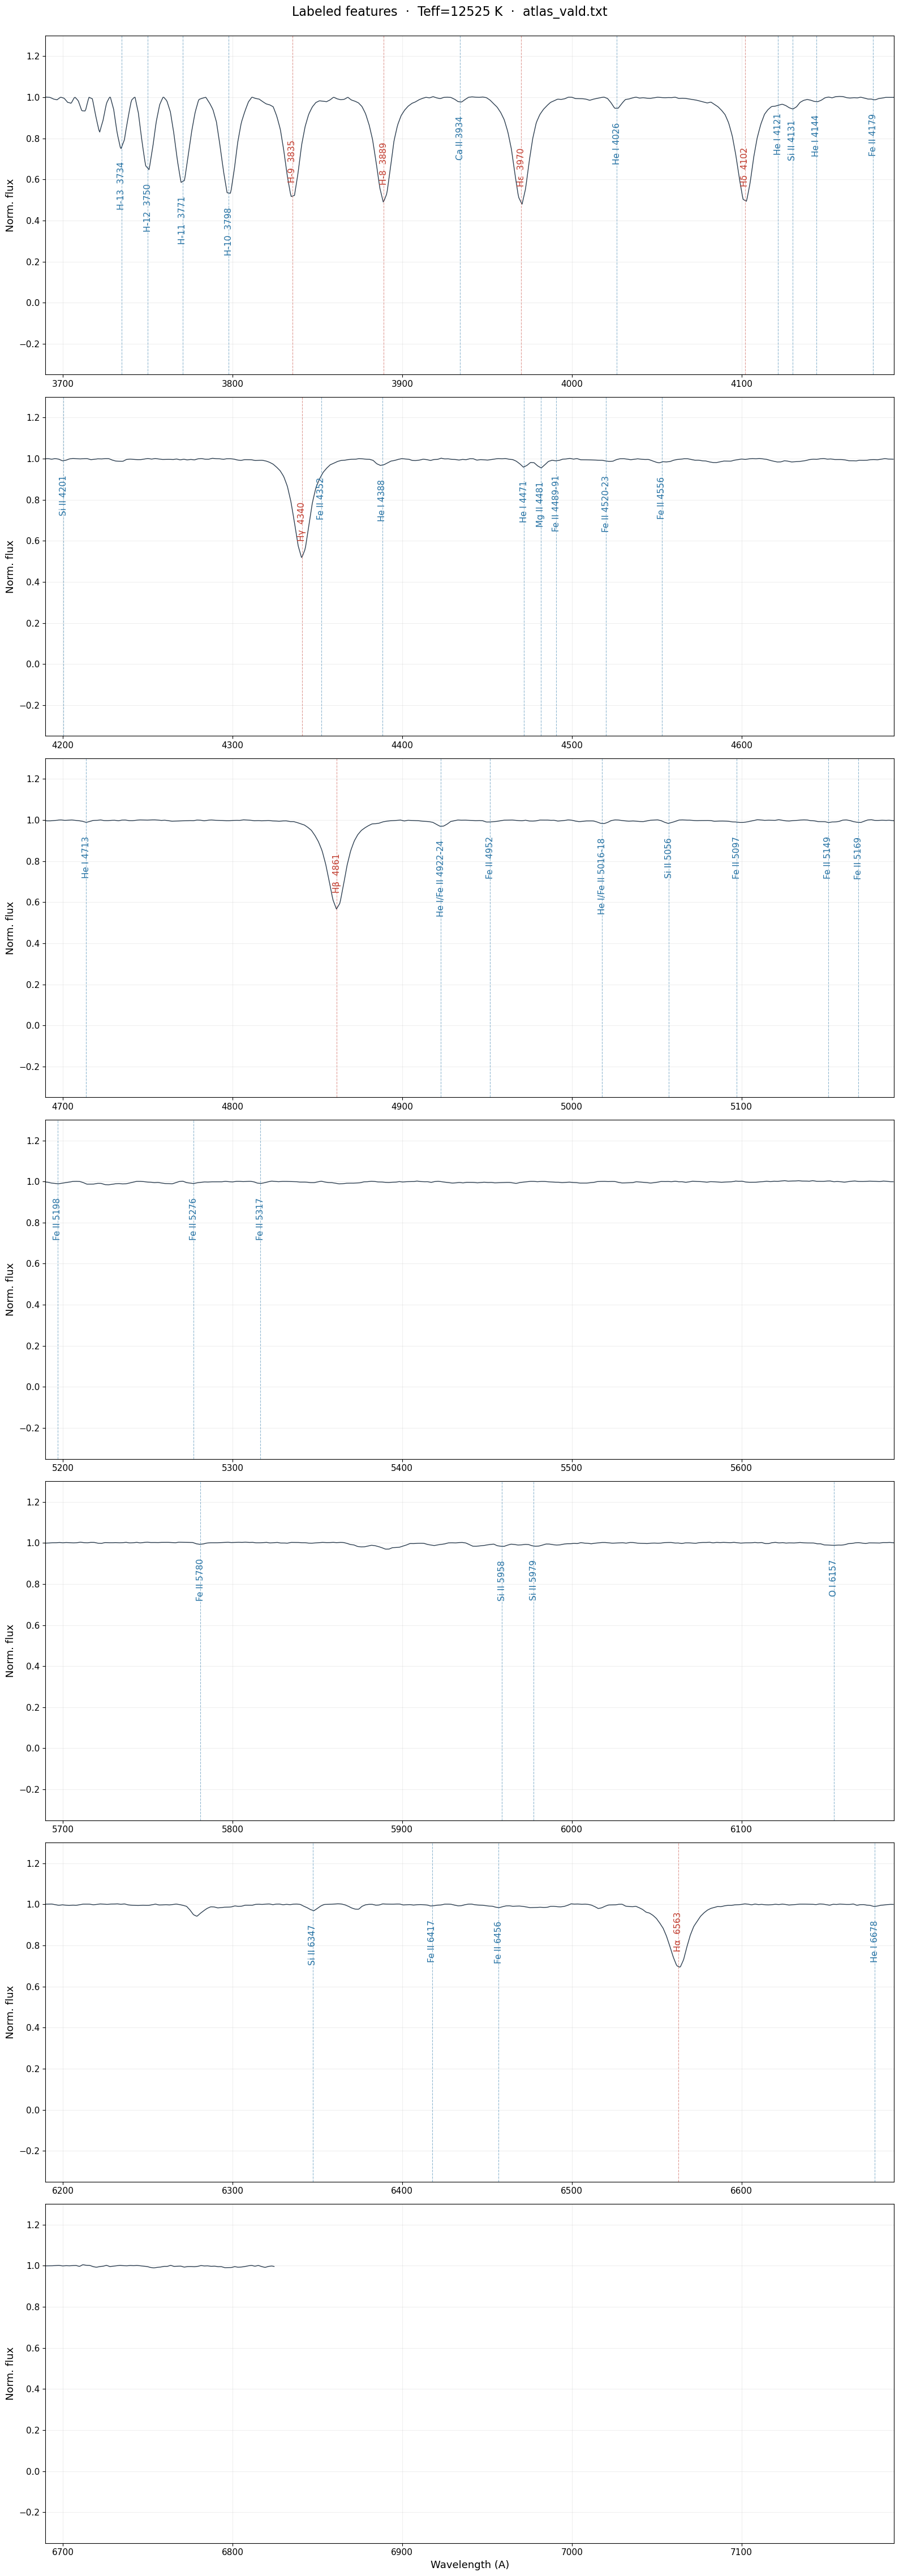

In [9]:
hdul = fits.open(SPEC_FITS_RECT)
flux = hdul[0].data.astype(float)
hdr  = hdul[0].header
wl   = hdr['CRVAL1'] + hdr['CDELT1'] * np.arange(len(flux))
hdul.close()

PANEL_WIDTH_A = 500
lo_all, hi_all = wl.min(), wl.max()
n_panels = int(np.ceil((hi_all - lo_all) / PANEL_WIDTH_A))

fig, axes = plt.subplots(n_panels, 1, figsize=(16, 6.5 * n_panels))
if n_panels == 1:
    axes = [axes]

for p, ax in enumerate(axes):
    lo = lo_all + p * PANEL_WIDTH_A
    hi = lo + PANEL_WIDTH_A
    m = (wl >= lo) & (wl <= hi)
    ax.plot(wl[m], flux[m], color='#2c3e50', lw=1.0)
    ax.set_xlim(lo, hi)
    ax.set_ylabel('Norm. flux', fontsize=13)
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(alpha=0.2)

    sub = features[(features.wavelength_A >= lo) & (features.wavelength_A <= hi) &
                  (features.labels != '')]
    # Extra vertical room above/below the trace for the larger, rotated annotation text so
    # labels don't run off the panel or collide with the curve itself.
    ax.set_ylim(-0.35, 1.30)
    for _, row in sub.iterrows():
        color = '#c0392b' if row['tag'] == 'Balmer' else '#2471a3'
        ax.axvline(row['wavelength_A'], color=color, lw=0.8, alpha=0.5, ls='--')
        ax.annotate(row['short_label'], xy=(row['wavelength_A'], 1.0 - row['amplitude']),
                    xytext=(0, -18 if row['tag'] != 'Balmer' else 18),
                    textcoords='offset points', rotation=90, fontsize=11,
                    ha='center', va='top' if row['tag'] != 'Balmer' else 'bottom', color=color)

axes[-1].set_xlabel('Wavelength (A)', fontsize=13)
fig.suptitle(f'Labeled features  ·  Teff={TEFF} K  ·  {"DEMO line list" if USE_DEMO_VALD else Path(VALD_FILE).name}',
             fontsize=16, y=1.0)
plt.tight_layout()
plt.show()